# Mini Project: Stroke Dataset Analysis 

**Author:** Yasir Binsaif  

**Purpose:**  

A **stroke** happens when the blood supply to part of the brain is blocked or when a blood vessel bursts, leading to cell death and brain damage. (Adapted from CDC)  

Predicting stroke risk early in people with high likelihood can help with prevention and prompt intervention.

This project aims at exploring patients' health data to identify patterns and answer:  
1. Do patients with high average glucose levels have a higher chance of developing a stroke? 
2. Do male and female patients show different stroke rates?  

Dataset Source: [Kaggle Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)



## Importing Libraries and Loading Data 

In [1]:
# Core libraries 
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# Visualization libraries 
import matplotlib.pyplot as plt 

# Set global plot style
plt.rcParams["figure.figsize"] = (6, 4)

# Load dataset 
stroke_df = pd.read_csv("healthcare-dataset-stroke-data.csv")


## Helper Functions 

In [2]:
def count_below(series, threshold):
    """
    Count patients below the given threshold.

    Args:
        series (pd.Series): The data column to evaluate.
        threshold (int or float): The cutoff value for comparison.  
    
    Returns:
        int: Number of patients below the threshold.
    """
    return (series < threshold).sum()

def count_above(series, threshold):
    """
    Count patients above the given threshold.

    Args:
        series (pd.Series): The data column to evaluate.
        threshold (int or float): The cutoff value for comparison.  
    
    Returns:
        int: Number of patients above the threshold.
    """
    return (series > threshold).sum()

def count_between(series, lower, upper):
    """
    Count patients between two values.

    Args:
        series (pd.Series): The data column to evaluate.
        lower (int or float): Lower bound.
        upper (int or float): Upper bound.    
    
    Returns:
        int: Number of patients between lower and upper bounds.
    """
    return (series.between(lower, upper)).sum()

## Data Inspection 

### Dataset Shape
How many rows and columns are in the dataset? 

In [3]:
stroke_df.shape

(5110, 12)

### Preview of the First 5 Rows 


In [4]:
stroke_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


The dataset contains the following variable types:

**Numeric variables**
- age (Age of the patient in years)
- avg_glucose_level (Average blood glucose, measured in mg/dL)
- bmi (Body Mass Index)

**Binary variables (0 = No, 1 = Yes)** 
- hypertension (Whether the patient has hypertension)
- heart_disease (Whether the patient has a heart disease)
- stroke (Whether the patient had a stroke) (target variable)

**Categorical variables** 
- gender (Male, Female, Other)  
- ever_married (Yes/No)  
- work_type (Private, Self-employed, Other)  
- Residence_type (Urban, Rural)  
- smoking_status (Formerly smoked, Never smoked, Smoked, Unknown)  

### Data Types and Non-Null Count

In [5]:
stroke_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


### Missing Values
Total missing Values in each column.

In [6]:
stroke_df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Percentage of values that are missing from `bmi`

In [7]:
missing_pct = (stroke_df["bmi"].isnull().sum()/len(stroke_df["bmi"])) * 100 
print(f"{round(missing_pct, 2)}%")

3.93%


### Descriptive Statistics 
For columns with numeric values 

In [8]:
pd.set_option("display.precision", 2)
stroke_df[["age","avg_glucose_level", "bmi"]].describe()

,age,avg_glucose_level,bmi
count,5110.00,5110.00,4909.00
mean,43.23,106.15,28.89
std,22.61,45.28,7.85
min,0.08,55.12,10.30
25%,25.00,77.25,23.50
50%,45.00,91.88,28.10
75%,61.00,114.09,33.10
max,82.00,271.74,97.60


For columns with binary values 

In [9]:
total_patients = len(stroke_df)

hypertension_patients_num = len(stroke_df[stroke_df["hypertension"] == 1])
heart_disease_patients_num = len(stroke_df[stroke_df["heart_disease"]== 1])
stroke_patients_num = len(stroke_df[stroke_df["stroke"] == 1])

print(f"Hypertension: {hypertension_patients_num} patients ({(hypertension_patients_num/total_patients) * 100:.2f}%)")
print(f"Heart disease: {heart_disease_patients_num} patients ({(heart_disease_patients_num/total_patients) * 100:.2f}%)")
print(f"Stroke: {stroke_patients_num} patients ({(stroke_patients_num/total_patients) * 100:.2f}%)")

Hypertension: 498 patients (9.75%)
Heart disease: 276 patients (5.40%)
Stroke: 249 patients (4.87%)


For columns with categorical values

In [10]:
num_of_males = len(stroke_df[stroke_df["gender"] == "Male"])
num_of_females = len(stroke_df[stroke_df["gender"] == "Female"])
num_of_other_genders = (~stroke_df["gender"].isin(["Male", "Female"])).sum()

print(f"Males: {num_of_males} patients ({(num_of_males/total_patients) * 100:.2f}%)")
print(f"Females: {num_of_females} patients ({(num_of_females/total_patients) * 100:.2f}%)")
print(f"Other: {num_of_other_genders} patients ({(num_of_other_genders/total_patients) * 100:.2f}%)")

Males: 2115 patients (41.39%)
Females: 2994 patients (58.59%)
Other: 1 patients (0.02%)


Other categorical columns (e.g., ever_married, work_type) are included in the dataset but are not explored further in this analysis.

## Data Cleaning

In [11]:
# Create a copy of the raw dataframe for cleaning. 
stroke_df_cleaned = stroke_df.copy()

### Standardize Column Names
- Convert column names to lowercase.
- Remove any leading/trailing whitespace.  
- Fix the inconsistency in `Residence_type` by aligning it with the rest. 

In [12]:
stroke_df_cleaned.columns = stroke_df_cleaned.columns.str.strip().str.lower() 

### Handle Missing Values

- Column `bmi` has approximately 3.9% missing values.  

- **Decision 1 (Drop vs Impute):** BMI is an important feature, therefore imputation was chosen.  

- **Decision 2 (Mean vs Median):** BMI distribution is right-skewed, so the median was used instead of the mean.  

- No other columns required action.  

In [13]:
# Check skewness 
print(f"Skewness of BMI column: {stroke_df_cleaned['bmi'].skew():.2f}") # > 0 = right skewness 

# Missing values before 
print(f"BMI missing values before: {stroke_df_cleaned["bmi"].isnull().sum()}")

# Replace missing values with median
stroke_df_cleaned["bmi"] = stroke_df_cleaned["bmi"].fillna(stroke_df_cleaned["bmi"].median())

# Missing values after 
print(f"BMI missing values after: {stroke_df_cleaned["bmi"].isnull().sum()}")

Skewness of BMI column: 1.06
BMI missing values before: 201
BMI missing values after: 0


### Check for Duplicates

- Checked for duplicates with `.duplicated().sum()`
- **Decision:** No duplicates were found, so no action was required. 

In [14]:
# Checking duplicates and printing the value
print(stroke_df_cleaned.duplicated().sum())

0


### Remove Irrelevant Column
- Column `ID` is only a unique identifier, it adds no analytical value, therefore it will be dropped. 

In [15]:
stroke_df_cleaned = stroke_df_cleaned.drop(columns=["id"])

### Validate Data Types 

- **Numeric columns** (age, avg_glucose_level, bmi) are already numeric. 
- **Categorical columns** (gender, ever_married, work_type, residence_type, smoking_status) need to be converted to `category`.  
- **Binary columns** (hypertension, heart_disease, stroke) will be treated as numeric for this analysis.  


In [16]:
# Check current data types 
print("\nBefore conversion:")
print(stroke_df_cleaned.dtypes)

# Convert categorical columns to category dtype
categorical_cols = ["gender", "ever_married", "work_type", "residence_type", "smoking_status"]
stroke_df_cleaned[categorical_cols] = stroke_df_cleaned[categorical_cols].astype("category")

# Verify conversion 
print("\nAfter conversion:")
print(stroke_df_cleaned[categorical_cols].dtypes)


Before conversion:
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

After conversion:
gender            category
ever_married      category
work_type         category
residence_type    category
smoking_status    category
dtype: object


### Check for Outliers and Inconsistent Values
- Set broad ranges for numeric variables (e.g., age, bmi, avg_glucose_level) to remove impossible or biologically implausible values.  
- Retain extreme but plausible cases for later outlier analysis.  
- Categorical values are consistent; no action required.

**Reasoning**
- **Age:** 2-120 years. Stroke in infants under 2 is extremely rare; values below 2 were removed. The upper limit is set at 120 years.  

- **Average glucose level:** 20-600 mg/dL. Values outside this range are physiologically implausible and likely data entry error. Extreme values within the range will be reviewed in the outlier analysis.  

- **BMI:** 10-100. Values outside this range are almost always invalid. Extreme but plausible BMIs (e.g, > 80) are retained for outlier inspection. 


##### Set boundaries 

In [17]:
# Length before cleaning 
n_rows_before_cleaning = len(stroke_df_cleaned)

# Set boundaries 
stroke_df_cleaned = stroke_df_cleaned[
    (stroke_df_cleaned["age"].between(2,120)) &
    (stroke_df_cleaned["avg_glucose_level"].between(20, 600)) &
    (stroke_df_cleaned["bmi"].between(10,100))
    ]

# Length after cleaning 
n_rows_after_cleaning = len(stroke_df_cleaned)

print(f"Rows before cleaning: {n_rows_before_cleaning} | After cleaning: {n_rows_after_cleaning} | Removed: {n_rows_before_cleaning - n_rows_after_cleaning}")


Rows before cleaning: 5110 | After cleaning: 4990 | Removed: 120


##### Outlier analysis 

- Calculate and display Q1, Q3, IQR, lower bound, and upper bound for **age**, **avg_glucose_level**, and **bmi**.

- For `age`, calculations and visualizations will be restricted to stroke patients only, since this distribution is more clinically relevant than that of the general population.

- Outliers were defined using the interquartile range method, which flags values much lower or higher than the bulk of the data.
    - Formula: 
        - Lower bound = Q1 - 1.5 × IQR
        - Upper bound = Q3 + 1.5 × IQR 

In [18]:
stroke_cases = stroke_df_cleaned[stroke_df_cleaned["stroke"] == 1]

# Create a dict for stats Q1, Q3, IQR, lower bound, and upper bound
cols_stats = {}

# Gather relevant data in one dict to loop over them and create stats + visuals. 
cols_to_plot = {
    "Age (stroke patients only)": (stroke_cases["age"], "Age (years)", "age")
   ,"Average Glucose Level": (stroke_df_cleaned["avg_glucose_level"], "Glucose (mg/dL)", "avg_glucose_level")
   ,"Body Mass Index": (stroke_df_cleaned["bmi"], "BMI (kg/m²)", "bmi"),
}

# Loop over cols_to_plot and add Q1, Q3, IQR, lower bound, and upper bound to cols_stats. 
for _, (series, _, col_name) in cols_to_plot.items():
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1 
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    cols_stats[col_name] = {"Q1": q1, "Q3": q3, "IQR": iqr, "Lower bound": lower_bound, "Upper bound": upper_bound}


# Create a dataframe from cols_stats
cols_stats_df = pd.DataFrame(cols_stats)

# Make age, avg_glucose_level, and bmi rows and display cols_stats_df.
print("Note: `age` statistics are based on stroke patients only.")
cols_stats_df.T


Note: `age` statistics are based on stroke patients only.


,Q1,Q3,IQR,Lower bound,Upper bound
age,59.00,78.00,19.00,30.50,106.50
avg_glucose_level,77.33,114.16,36.83,22.08,169.41
bmi,24.10,33.00,8.90,10.75,46.35



Visualize outliers in **age**, **avg_glucose_level**, **bmi** using boxplots. 

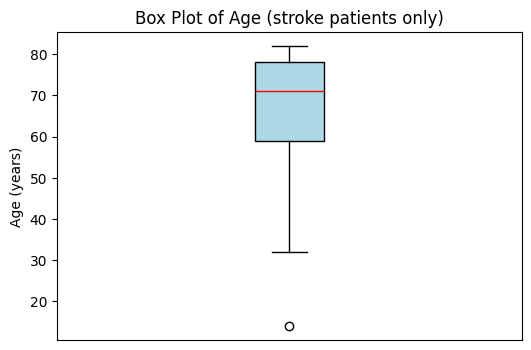

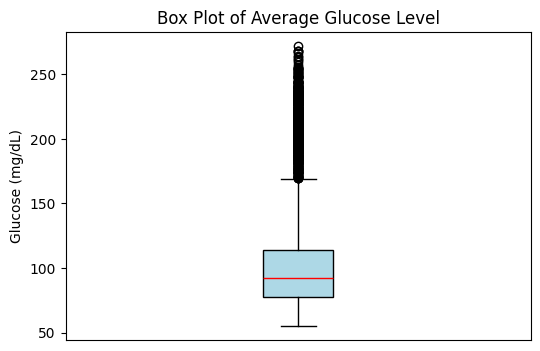

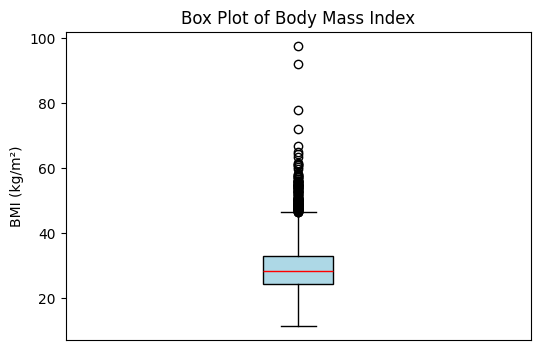

In [19]:
# Create a boxplot for each column. 
for title_name, (series, y_label, _) in cols_to_plot.items():
    plt.figure()
    plt.boxplot(
        series,
        patch_artist= True,
        showfliers=True,
        boxprops= dict(facecolor = "lightblue"),
        medianprops= dict(color = "red")
        
    )
    plt.xticks([])
    plt.title(f"Box Plot of {title_name}")
    plt.ylabel(y_label)
    plt.show()

Examine histograms to assess the overall distribution of these variables. 

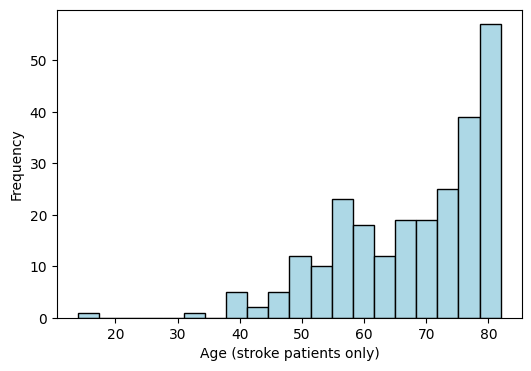

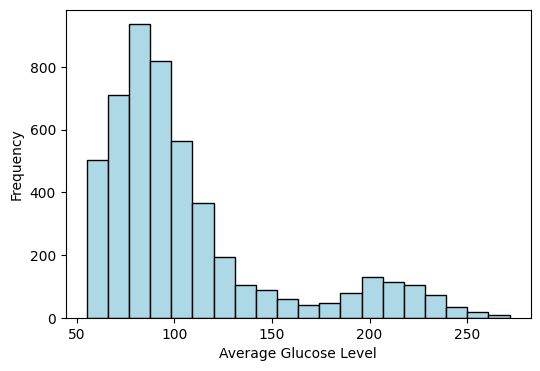

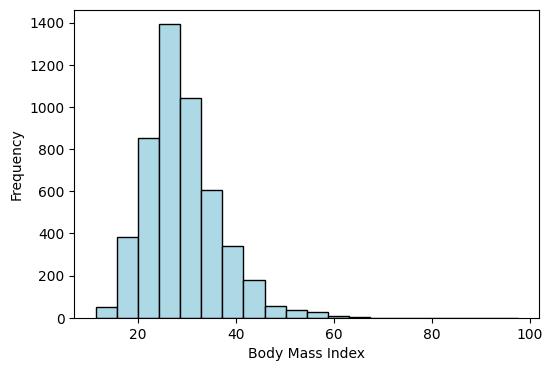

In [20]:
# Create a histogram for each column. 
for title_name, (series, _, _) in cols_to_plot.items():
    plt.figure()
    plt.hist(series, bins=20, color = "lightblue", edgecolor = "black")
    plt.xlabel(title_name)
    plt.ylabel("Frequency")
    plt.show()

Apply outlier treatment where necessary. 

- For `age`, the values conform with the expected age range for stroke occurrence (predominantly 30 or older). Only one patient is recorded below 30; while uncommon, this is clinically plausible (e.g., congenital or vascular conditions). Therefore, no outliers were removed.  

- For `avg_glucose_level`, there are 625 patients that have an average glucose level above 169.41 mg/dL (upper bound), of which 434 patients have an average glucose level between 200 and 300 mg/dL; those values represent clinically meaningful cases rather than data errors. Therefore, no action will be taken. 

- For `bmi`, No outliers below the lower bound were detected. For patients above the upper bound: 
    - Retain patients with BMI between 40-70 to preserve possible cases of morbid obesity. 
    - Patients with a BMI > 70 will be reviewed on a case-by-case basis.


`age` (stroke patients only)

In [21]:
# Create a series for age
age = stroke_cases["age"]

# Patients where age is < 30.5 (lower bound) 
patients_below_30 = count_below(age, 30.5)

# Patients where age is > 106.5 (upper bound)
patients_above_106 = count_above(age, 106.5)

print(
    f"Patients below 30: {patients_below_30} |",
    f"Patients above 106: {patients_above_106}"
)

Patients below 30: 1 | Patients above 106: 0


`avg_glucose_level` (all patients)

In [22]:
# Total number of patients
patients_after_cleaning = stroke_df_cleaned.shape[0]

# Create a series for avg_glucose_level
glucose = stroke_df_cleaned["avg_glucose_level"]


# Patients with average glucose level < 22.08 mg/dL (lower bound)
low_glucose = count_below(glucose,22.08)

# Patients with average glucose level > 169.41 mg/dL (upper bound)
high_glucose = count_above(glucose, 169.41)
high_glucose_pct = (high_glucose/patients_after_cleaning) * 100

# Patients with average glucose level >= 200 and <= 300 mg/dL 
very_high_glucose = count_between(glucose, 200, 300)
very_high_glucose_pct = (very_high_glucose/patients_after_cleaning) * 100

# Patients with average glucose level > 300 
extreme_glucose = count_above(glucose, 300)


# Build dataframe
glucose_stats = pd.DataFrame([
    {"condition": "Glucose < 22.08 mg/dL", "count": low_glucose, "percent": 0.0},
    {"condition": "Glucose > 169.41 mg/dL", "count": high_glucose, "percent": high_glucose_pct},
    {"condition": "Glucose 200-300 mg/dL", "count": very_high_glucose, "percent": very_high_glucose_pct},
    {"condition": "Glucose > 300 mg/dL", "count": extreme_glucose, "percent": 0.0}
])

# Display glucose dataframe
display(glucose_stats)

,condition,count,percent
0,Glucose < 22.08 mg/dL,0,0.00
1,Glucose > 169.41 mg/dL,625,12.53
2,Glucose 200-300 mg/dL,434,8.70
3,Glucose > 300 mg/dL,0,0.00


`bmi` (all patients)

In [ ]:
# Create a series for bmi 
bmi = stroke_df_cleaned["bmi"]

# Patients with a BMI below 10.75 (lower bound)
low_bmi_patients = count_below(bmi, 10.75)

# Patients with a BMI above 46.35 (upper bound)
high_bmi_patients = count_above(bmi, 46.35)


print(
    f"Patients that have a BMI below lower bound {low_bmi_patients} |",
    f"Patients that have a BMI above upper bound {high_bmi_patients}"
)

Patients that have a BMI below lower bound 0 | Patients that have a BMI above upper bound 124


**Case-by-case review**

- **BMI 71.9:** Very high average glucose. Clinically plausible.  
    - **Decision:** Retain (extreme but plausible).  

- **BMI 78:** Hypertension + normal/low glucose. Clinically plausible.  
    - **Decision:** Retain (extreme but plausible). 

- **BMI 97.6:** Hypertension + low glucose + very young. Highly implausible.  
    - **Decision:** Drop. 
 
- **BMI 92:** Hypertension + low glucose. Implausible for such extreme BMI.  
    - **Decision:** Drop. 

In [24]:
stroke_df_cleaned[stroke_df_cleaned["bmi"] > 70]

,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
544,Male,42.0,0,0,Yes,Private,Rural,210.48,71.9,never smoked,0
928,Female,23.0,1,0,No,Private,Urban,70.03,78.0,smokes,0
2128,Male,17.0,1,0,No,Private,Rural,61.67,97.6,Unknown,0
4209,Male,38.0,1,0,Yes,Private,Rural,56.90,92.0,never smoked,0


Drop the two highly implausible values in `bmi`.

In [25]:
# Total number of patients before.
print("Before:", stroke_df_cleaned.shape[0])

# Drop 
stroke_df_cleaned = stroke_df_cleaned.drop([2128, 4209], errors="ignore")

# Total number of patients after.
print("After:", stroke_df_cleaned.shape[0])

Before: 4990
After: 4988


## Exploratory Data Analysis (EDA)

This section examines the dataset to address the two guiding questions: 
1. Do patients with high average glucose levels have a higher chance of developing a stroke? 
2. Do male and female patients show different stroke rates?  

### Question 1: Average Glucose Level vs Stroke

#### Visualization

Boxplot comparing glucose distribution between stroke and non-stroke patients. 

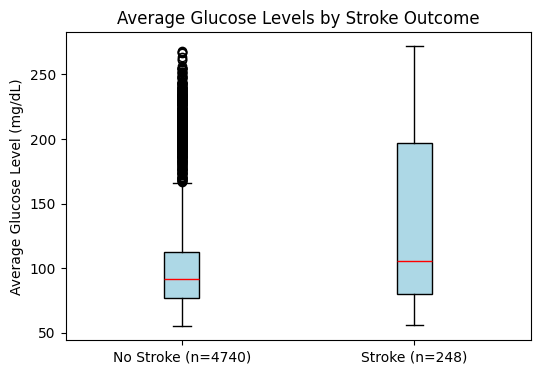

In [26]:
# Separate groups
glucose_no_stroke = stroke_df_cleaned[stroke_df_cleaned["stroke"] == 0]["avg_glucose_level"]
glucose_stroke = stroke_df_cleaned[stroke_df_cleaned["stroke"] == 1]["avg_glucose_level"]

# Sample sizes 
n_no_stroke = len(glucose_no_stroke)
n_stroke = len(glucose_stroke)

# Boxplot
plt.figure()
plt.boxplot(
    [glucose_no_stroke, glucose_stroke],
    tick_labels=[f"No Stroke (n={n_no_stroke})", f"Stroke (n={n_stroke})"],
    patch_artist=True,
    boxprops=dict(facecolor = "lightblue"),
    medianprops=dict(color= "red")
)
plt.title("Average Glucose Levels by Stroke Outcome")
plt.ylabel("Average Glucose Level (mg/dL)")
plt.show()

Summary statistics of glucose levels by stroke outcome. (0=No Stroke, 1=Stroke)

In [27]:
stroke_df_cleaned.groupby("stroke")["avg_glucose_level"].describe()

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4740.0,105.03,44.12,55.12,77.22,91.56,112.85,267.76
1,248.0,132.80,61.92,56.11,80.05,105.57,196.76,271.74


Stroke percentage by glucose category. 

- To complement the boxplot, glucose values were categorized using standard clinical cutoffs: 

    - **Normal (<100 mg/dL)**
    - **Prediabetic (100-125 mg/dL)** 
    - **Diabetic (≥126 mg/dL)**

For each category, the stroke rate (%) was calculated and displayed.  
This visualization highlights whether higher glucose categories are associated with greater risk of stroke. 

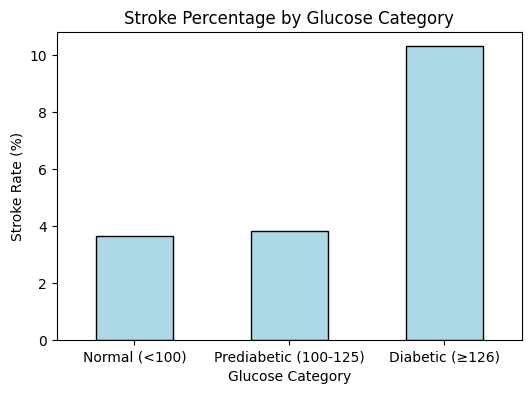

In [28]:
# Define bins and labels 
bins = [0, 100, 126, glucose.max()]
labels = ["Normal (<100)", "Prediabetic (100-125)", "Diabetic (≥126)"]

# Create a new column of categories
stroke_df_cleaned["glucose_category"] = pd.cut(glucose, bins=bins, labels=labels, right=False)

# Group by glucose category and calculate stroke rate 
stroke_rate = stroke_df_cleaned.groupby("glucose_category", observed=False)["stroke"].mean() * 100

# bar chart 
plt.figure(figsize=(6,4))
stroke_rate.plot(kind="bar", color="lightblue", edgecolor="black")

plt.title("Stroke Percentage by Glucose Category")
plt.ylabel("Stroke Rate (%)")
plt.xlabel("Glucose Category")
plt.xticks(rotation=0)
plt.show()

#### Statistical Tests 
- **Primary test:** Mann-Whitney U 
    - **Reason:** Glucose data is skewed and contains outliers, violating t-test assumptions.    
- **Sensitivity check:** Welch's t-test on log-transformed glucose
    - **Reason:** Provides a parametric confirmation of the non-parametric results. 

##### Mann-Whitney U Test

In [ ]:
# n1 = glucose_no_stroke, n2 = glucose_stroke
U_value, p = mannwhitneyu(glucose_no_stroke, glucose_stroke, alternative="two-sided")

# Effect size (rank-biserial correlation)
rbc = 1 - (2 * U_value ) / (n_no_stroke * n_stroke)

# Display results
print(f"U = {U_value:.0f}, p-value = {p:.3e}, n1 = {n_no_stroke}, n2 = {n_stroke}, rank-biserial correlation (effect size) = {rbc:.3f}")

U = 456662, p-value = 3.028e-09, n1 = 4740, n2 = 248, rank-biserial correlation (effect size) = 0.223


##### Welch's t-test

#### Logistic Regression

#### Interpretation 

### Question 2: Gender vs Stroke 